## **Importing Necessary Libraries**

In [ ]:
import pandas as pd
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
)
from sklearn.model_selection import train_test_split

## **Loading Preprocessed Dataset**

In [2]:
df = pd.read_csv(r"E:\Arshdeep CL NLP Project\Dataset\preprocessed\fake_news_cleaned.csv").dropna(subset=["lemmatized_text", "label"])
texts = df["lemmatized_text"].tolist()
labels = df["label"].tolist()

## **Train-Test Split**

In [ ]:
_, val_texts, _, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# **Loading Tokenizer and Model (Fine-Tuned)**

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(r"E:\Arshdeep CL NLP Project\models\distilbert_finetuned")
model = DistilBertForSequenceClassification.from_pretrained(r"E:\Arshdeep CL NLP Project\models\distilbert_finetuned")

In [5]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## **Tokenize & Batch**

In [ ]:
batch_size = 16
all_preds = []
all_probs = []

In [ ]:
for i in range(0, len(val_texts), batch_size):
    batch_texts = val_texts[i : i + batch_size]
    enc = tokenizer(batch_texts, truncation=True, padding=True, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    
    with torch.no_grad():
        outputs = model(**enc)
        logits = outputs.logits
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # this is the probability of "Real" class!
        preds  = torch.argmax(logits, axis=1).cpu().numpy()
    
    all_probs.extend(probs.tolist())
    all_preds.extend(preds.tolist())

In [8]:
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
val_labels = np.array(val_labels)

## **Computing Metrics**

In [ ]:
acc   = accuracy_score(val_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(val_labels, all_preds, average="binary")
auc   = roc_auc_score(val_labels, all_probs)

In [10]:
print("\nClassification Report:")
print(classification_report(val_labels, all_preds, target_names=["Fake","Real"]))


Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4572
        Real       1.00      1.00      1.00      4265

    accuracy                           1.00      8837
   macro avg       1.00      1.00      1.00      8837
weighted avg       1.00      1.00      1.00      8837



## **🖨️Printing the Confusion Matrix**

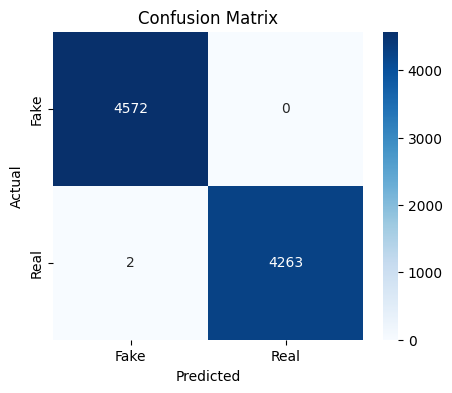

In [ ]:
cm = confusion_matrix(val_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"], yticklabels=["Fake","Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## **ROC Curve**

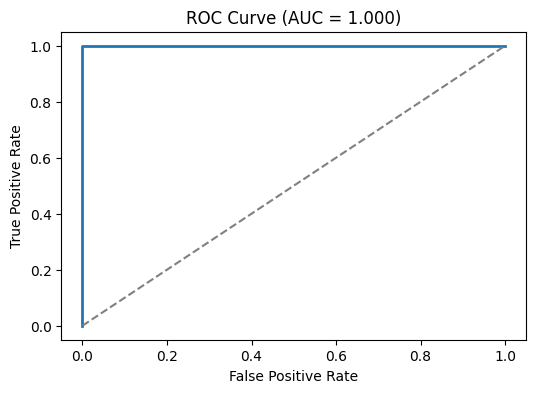

In [ ]:
fpr, tpr, thresholds = roc_curve(val_labels, all_probs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, lw=2)
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.show()